In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('loan_approval_data.csv')

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [10]:
# As the target column - Loan_Approved has only two classes (Yes/No)
# Thus it is a Binary Classification problem.

## Handle Missing Values

In [ ]:
#For numerical data = mean/median can be used
#For categorical data = Like gender = M/F; mode can be used

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [15]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [18]:
numerical_cols = df.select_dtypes(include=[ 'float64']).columns

In [19]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [24]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

## EDA

In [26]:
#How balanced the classes are ?

classes_counts = df['Loan_Approved'].value_counts()

In [27]:
classes_counts

,count
Loan_Approved,
No,702
Yes,298


Text(0.5, 1.0, 'Is loan approved or not?')

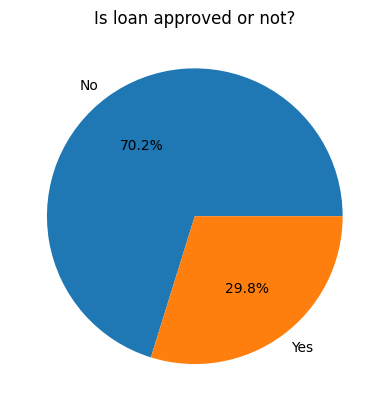

In [29]:
plt.pie(classes_counts,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is loan approved or not?")

[Text(0, 0, '722'), Text(0, 0, '278')]

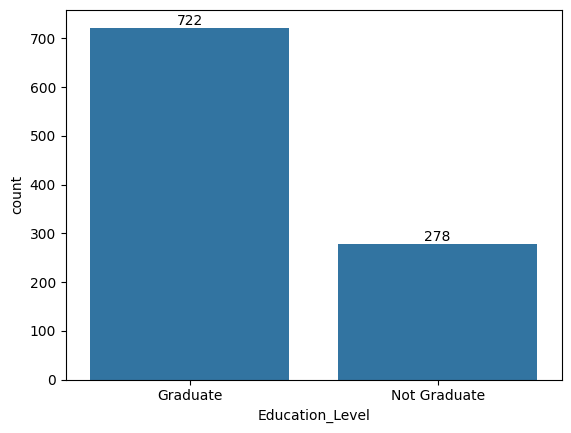

In [34]:
#Analyze categories

# gender_count = df['Gender'].value_counts()
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

education_count = df['Education_Level'].value_counts()
ax = sns.barplot(education_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

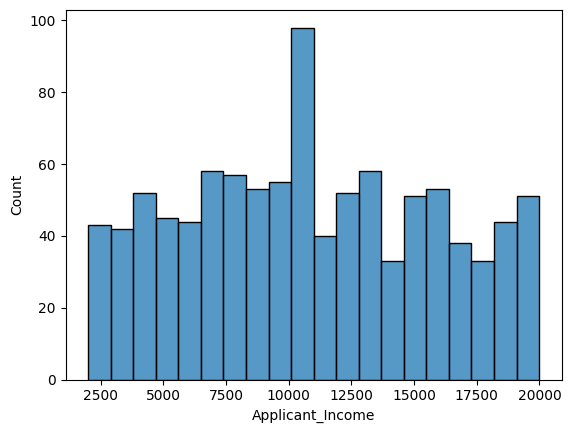

In [35]:
#Analyze income

sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

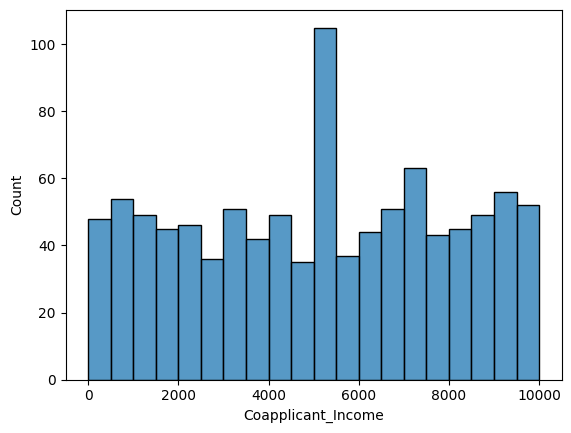

In [36]:
sns.histplot(
    data = df,
    x = 'Coapplicant_Income',
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

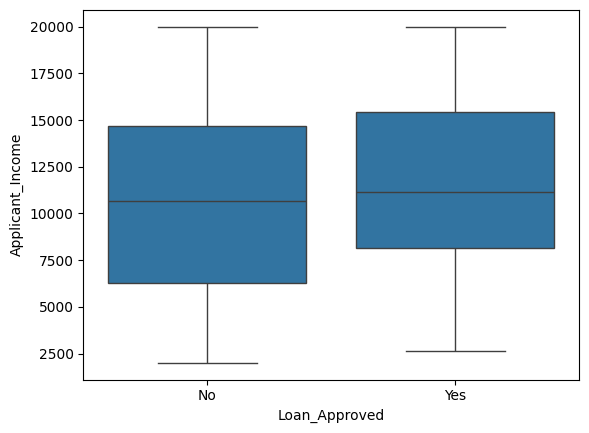

In [37]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

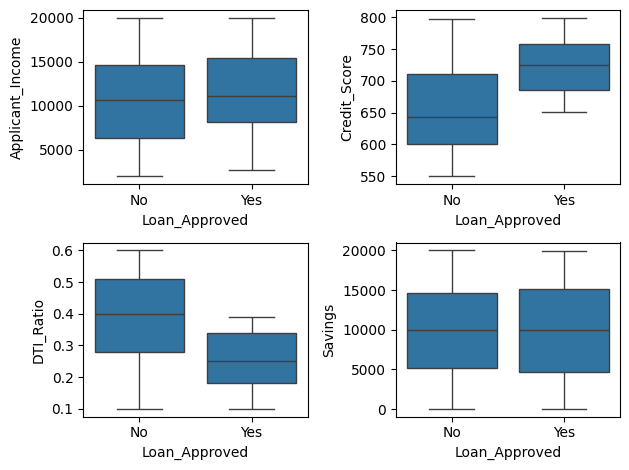

In [42]:
fig,axes = plt.subplots(2,2)

sns.boxplot(
    ax = axes[0,0],
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)
sns.boxplot(
    ax = axes[0,1],
    data=df,
    x="Loan_Approved",
    y="Credit_Score"
)
sns.boxplot(
    ax = axes[1,0],
    data=df,
    x="Loan_Approved",
    y="DTI_Ratio"
)
sns.boxplot(
    ax = axes[1,1],
    data=df,
    x="Loan_Approved",
    y="Savings"
)

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

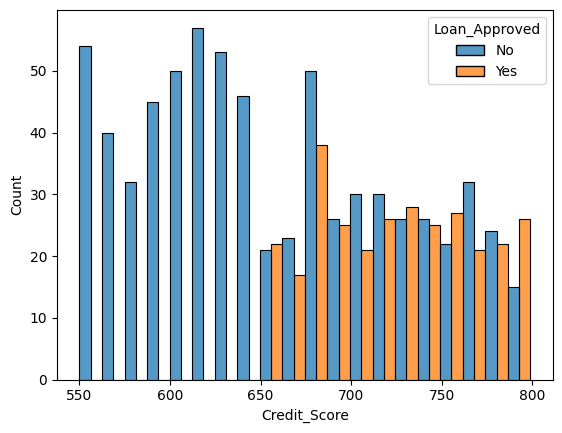

In [44]:
#Credit_score with loan_approved data
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

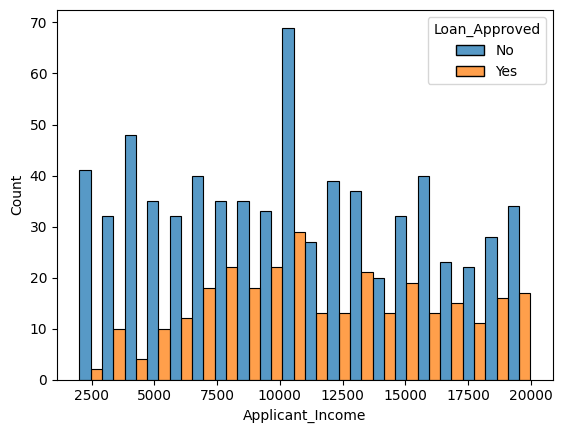

In [45]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

In [49]:
#Remove Applicant_ID, as it does not have any use.
df = df.drop('Applicant_ID',axis=1)

In [50]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
